# Module 05 — the ΔH model: a Transformer that predicts, per family of vibrations, how a cheap Hessian must be corrected

**Task type (declared for the rubric): sequence modelling with a Transformer.** A molecule enters as a *sequence of normal-mode tokens* —
one token per vibration of a cheap density-functional Hessian (B3LYP/6-31G*) — and the network predicts the *family block* of the
correction matrix towards a better level of theory (ωB97X/6-31G* here as the stand-in for coupled cluster): the block's diagonal is the
per-mode band shift, its off-diagonal elements are the couplings between modes of one family. A second head predicts which
mode pairs carry a large correction at all (the *support*). This is the learned prior of the Δ-probed IR pipeline (plan 05): it tells the
expensive measurement where to look.

**Dataset.** The project's own corpus of molecule Hessians, computed by its corpus factory at two levels of theory on the same
geometries (`data/corpus_release/layerA2_2026-09-23.npz` with its manifest of checksums; released on Zenodo with a DOI before submission).
Computed ab initio data — public, not synthetic in the sense of generated by a model, not AI-generated, not used in Modules 02–04
(those used the NASA PAHdb and NIST laboratory libraries). Recipe, splits, seeds and the one controlled change were fixed in
`RECIPE.md` before this notebook existed (dated amendments of 13 and 19 September 2026 restate the target as the family block).

Sections: **Setup · 1 Load and inspect · 2 Baseline model · 3 Training · 4 Controlled comparison · 5 Evaluation · 6 Summary**.

## Setup

In [1]:
import json, hashlib, math, os, sys, time
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn as nn
%matplotlib inline
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path("..") / "m05"))
from deltah_model import DeltaHModel, DeltaHConfig, block_loss
torch.set_num_threads(int(os.environ.get("M05_THREADS", "2")))
QUICK = os.environ.get("M05_QUICK") == "1"          # pipeline check only: fewer epochs, one seed — never a result
RELEASE = Path("..") / "data" / "corpus_release" / "layerA2_2026-09-23.npz"
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
FAMILIES = ["CH-stretch", "CH-oop", "ring-ip", "other"]
THETA = 0.1                                          # pair label: |K_ij| >= THETA * max_k |K_kk| (RECIPE)
EPOCHS, SEEDS = (3, [0]) if QUICK else (30, [0, 1, 2])
print("torch", torch.__version__, "| release:", RELEASE.name, RELEASE.exists(), "| quick mode:", QUICK)

torch 2.14.0+cpu | release: layerA2_2026-09-23.npz True | quick mode: False


## 1. Load and inspect the dataset

Each molecule is one sequence. A token holds only cheap-level information: ω/1000, the family one-hot, the mass-weighted shares of C, H,
N and O in the motion, a localisation number, the out-of-plane share and twelve atom-environment classes (which kinds of hydrogens and
carbons move). The target `K` is the correction matrix in the cheap-level mode basis, in cm⁻¹; the model never sees it as input.

In [2]:
z = np.load(RELEASE); man = json.load(open(str(RELEASE).replace(".npz", "_manifest.json")))
ids, mask, tokens, family, omega, K = z["ids"], z["mask"], z["tokens"], z["family"], z["omega_cm"], z["K"]
N, M, D = tokens.shape
print(f"{N} molecules, up to {M} modes each, {D} token features; total modes {int(mask.sum()):,}; built {man['built_utc']} UTC from {man['n_molecules']} folders")
print("token layout:", man["token_layout"]); print("target:", man["target"])
print("dtypes:", tokens.dtype, family.dtype, K.dtype, "| shapes:", tokens.shape, family.shape, K.shape)
print("modes per family:", man["mode_counts_per_family"])

224 molecules, up to 84 modes each, 23 token features; total modes 14,607; built 2026-09-23 05:54:52 UTC from 224 folders
token layout: omega/1000 | family one-hot (4: CH-stretch, CH-oop, ring-ip, other) | shares C,H,N,O | localisation | oop share | 12 environment classes
target: K_ij = L_i^T dH_mw L_j / (2 sqrt(w_i w_j)) in cm-1, B3LYP mode basis, dH = H(wB97X) - H(B3LYP)
dtypes: float32 int64 float32 | shapes: (224, 84, 23) (224, 84) (224, 84, 84)
modes per family: {'CH-stretch': 1989, 'CH-oop': 1146, 'ring-ip': 5652, 'other': 5820}


In [3]:
# representative samples: three molecules, first six modes each
rows = []
for i in [0, N // 2, N - 1]:
    for j in range(min(6, int(mask[i].sum()))):
        rows.append(dict(molecule=ids[i], mode=j, omega_cm=round(float(omega[i, j]), 1), family=FAMILIES[family[i, j]],
                         share_C=round(float(tokens[i, j, 5]), 2), share_H=round(float(tokens[i, j, 6]), 2), K_ii_cm=round(float(K[i, j, j]), 1)))
pd.DataFrame(rows)

,molecule,mode,omega_cm,family,share_C,share_H,K_ii_cm
0,A2_00b0ff5a24,0,20.2,other,0.05,0.02,149.5
1,A2_00b0ff5a24,1,62.5,other,0.63,0.12,20.9
2,A2_00b0ff5a24,2,114.6,other,0.85,0.12,13.3
3,A2_00b0ff5a24,3,121.3,other,0.81,0.18,14.2
4,A2_00b0ff5a24,4,187.9,other,0.41,0.07,5.8
5,A2_00b0ff5a24,5,206.2,other,0.81,0.18,16.5
6,A2_25fed68b27,0,71.4,other,0.64,0.07,14.0
7,A2_25fed68b27,1,116.5,other,0.78,0.18,8.4
8,A2_25fed68b27,2,193.3,other,0.75,0.10,10.1
9,A2_25fed68b27,3,199.5,other,0.63,0.09,6.1


padded positions: 4,209 of 18,816; K symmetric to 1.5e-08 cm⁻¹
diagonal (first-order shifts): median +13.1, 5–95 % -1.5 … +44.0 cm⁻¹
couplings |K_ij|: median 0.38, 95 % 4.23, max 180.3 cm⁻¹


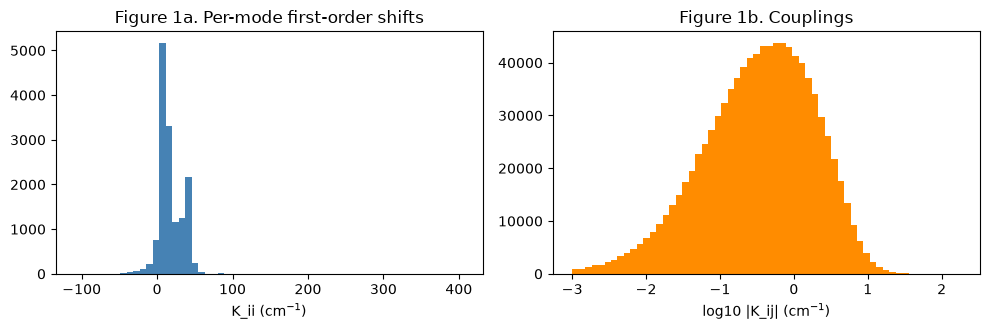

In [4]:
# data quality: padding, symmetry of K, magnitude of the diagonal and couplings, family balance
diag = np.concatenate([np.diag(K[i])[mask[i]] for i in range(N)])
off = np.concatenate([K[i][np.ix_(mask[i], mask[i])][~np.eye(int(mask[i].sum()), dtype=bool)] for i in range(N)])
asym = max(float(np.abs(K[i][np.ix_(mask[i], mask[i])] - K[i][np.ix_(mask[i], mask[i])].T).max()) for i in range(N))
print(f"padded positions: {int((~mask).sum()):,} of {mask.size:,}; K symmetric to {asym:.1e} cm⁻¹")
print(f"diagonal (first-order shifts): median {np.median(diag):+.1f}, 5–95 % {np.percentile(diag, 5):+.1f} … {np.percentile(diag, 95):+.1f} cm⁻¹")
print(f"couplings |K_ij|: median {np.median(np.abs(off)):.2f}, 95 % {np.percentile(np.abs(off), 95):.2f}, max {np.abs(off).max():.1f} cm⁻¹")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(diag, bins=60, color="steelblue"); axes[0].set_xlabel("K_ii (cm$^{-1}$)"); axes[0].set_title("Figure 1a. Per-mode first-order shifts")
axes[1].hist(np.log10(np.abs(off) + 1e-3), bins=60, color="darkorange"); axes[1].set_xlabel("log10 |K_ij| (cm$^{-1}$)"); axes[1].set_title("Figure 1b. Couplings")
plt.tight_layout(); fig.savefig(FIG / "fig1_targets.png", dpi=140); plt.show()

*Preprocessing considerations.* Sequences have different lengths, so molecules are padded to the longest one and a mask keeps padding
out of attention, loss and metrics. Targets are in cm⁻¹ and are not standardised: the loss is a plain squared error over the filled family-block
elements, so a 1 cm⁻¹ error means the same thing everywhere. Splits are **by molecule** (a hash of the identifier: 80 % train, 10 %
validation, 10 % test), never by mode, because the modes of one molecule are strongly correlated.

In [5]:
def split_of(mol_id):
    h = int(hashlib.sha1(mol_id.encode()).hexdigest(), 16) % 10
    return "test" if h == 0 else ("val" if h == 1 else "train")
split = np.array([split_of(s) for s in ids])
idx = {s: np.where(split == s)[0] for s in ("train", "val", "test")}
print({s: len(v) for s, v in idx.items()})
T = dict(tokens=torch.tensor(tokens), family=torch.tensor(family).clamp_min(0), mask=torch.tensor(mask), K=torch.tensor(K),
         charge=torch.tensor(z["charge"]).long(), mult=torch.tensor(z["mult"]).long(), omega=torch.tensor(omega))

{'train': 186, 'val': 18, 'test': 20}


## 2. Baseline model (PyTorch)

The ΔH model (design sheet `architecture/50_deltaH_model_components.mmd`, code `m05/deltah_model.py`): a **token embedding** (a linear layer
with GELU and LayerNorm on the 23 mode features, plus two learned molecule tokens for charge and spin multiplicity, so that cations can join
later without a change of architecture), an **encoder-only Transformer backbone** (2 layers, 4 heads, width 64, feed-forward 256, dropout 0.1,
pre-norm), and two output heads on the contextualised mode vectors: the **block head** reads the pair of vectors (i, j) together with their
frequencies and writes K_ij, applied to every pair inside a family; the **pair head** writes a logit for "this pair carries a large correction".

*Why a Transformer.* The input is a set of variable length whose elements interact through pairs (a coupling is a statement about two
modes at once); self-attention is permutation-aware and sees every pair in one layer. A recurrent network would impose an order the
modes do not have; a convolution would impose locality in frequency that couplings do not respect. *Why small.* The corpus is hundreds of
molecules, not millions; the design keeps 136 k parameters and relies on the physics in the tokens rather than on capacity.

In [6]:
cfg = DeltaHConfig(n_families=4, n_irreps=0, n_env=13, n_layers=2)    # n_env 13 = 12 environment classes + the out-of-plane share
model = DeltaHModel(cfg); assert cfg.d_in == D, (cfg.d_in, D)
print(model); print("parameters:", f"{model.n_parameters():,}")

DeltaHModel(
  (embed): TokenEmbedding(
    (mode_mlp): Sequential(
      (0): Linear(in_features=23, out_features=64, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
    (charge_emb): Embedding(5, 64)
    (mult_emb): Embedding(5, 64)
    (type_emb): Embedding(3, 64)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (drop): Dropout(p=0.1, inplace=False)
  )
  (backbone): Backbone(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_a

## 3. Training

Loss = block loss (mean squared error over the filled family-block elements; the block rule of 19 September) + the pair head's binary
cross-entropy with the positive class weighted by its rarity. AdamW (lr 1e-3, weight decay 1e-2), batches of 8 molecules, early stopping on
the validation loss, three seeds. Training progress is shown as loss curves.

In [7]:
def batches(ix, bs, rng=None):
    ix = np.array(ix);
    if rng is not None: rng.shuffle(ix)
    for s in range(0, len(ix), bs): yield ix[s:s + bs]

def pair_labels(Kb, maskb):
    scale = (torch.diagonal(Kb, dim1=1, dim2=2).abs() * maskb).amax(1)                      # max_k |K_kk| per molecule
    lab = (Kb.abs() >= THETA * scale[:, None, None]).float()
    eye = torch.eye(Kb.shape[1], dtype=torch.bool)[None]
    valid = maskb[:, :, None] & maskb[:, None, :] & ~eye
    return lab, valid

def losses(m, b):
    out = m(T["tokens"][b], T["family"][b], T["charge"][b], T["mult"][b], T["mask"][b])
    lb = block_loss(out["block"], T["K"][b], T["family"][b], T["mask"][b])
    lab, valid = pair_labels(T["K"][b], T["mask"][b])
    pos = lab[valid].mean().clamp(1e-3, 0.5); w = torch.where(lab > 0, (1 - pos) / pos, torch.ones_like(lab))
    lp = (nn.functional.binary_cross_entropy_with_logits(out["pair_logits"], lab, weight=w, reduction="none") * valid).sum() / valid.sum().clamp_min(1)
    return lb, lp, out

def train(cfg, seed, epochs=EPOCHS, bs=8, patience=6):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    m = DeltaHModel(cfg); opt = torch.optim.AdamW(m.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    hist = {"train": [], "val": []}; best = (float("inf"), None, 0)
    for ep in range(epochs):
        m.train(); tl = []
        for b in batches(idx["train"], bs, rng):
            lb, lp, _ = losses(m, torch.tensor(b)); loss = lb + lp
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step(); tl.append(float(loss))
        m.eval()
        with torch.no_grad():
            lb, lp, _ = losses(m, torch.tensor(idx["val"])); vl = float(lb + lp)
        hist["train"].append(float(np.mean(tl))); hist["val"].append(vl)
        if vl < best[0] - 1e-4: best = (vl, {k: v.clone() for k, v in m.state_dict().items()}, ep)
        elif ep - best[2] >= patience: break
    m.load_state_dict(best[1]); m.eval()
    return m, hist, best[2]

t0 = time.time(); runs = {"baseline": [train(cfg, s) for s in SEEDS]}
print(f"baseline: {len(SEEDS)} seed(s), best epochs {[r[2] for r in runs['baseline']]}, {time.time() - t0:.0f} s")

/tmp/ipykernel_41652/343023715.py:29: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step(); tl.append(float(loss))


baseline: 3 seed(s), best epochs [29, 25, 29], 489 s


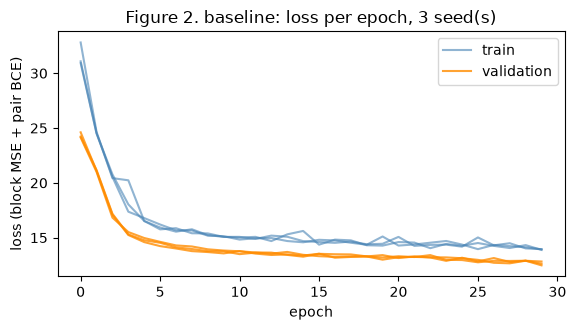

In [8]:
def plot_curves(runs, name, fname):
    fig, ax = plt.subplots(figsize=(6, 3.4))
    for k, (m, h, be) in enumerate(runs):
        ax.plot(h["train"], color="steelblue", alpha=0.6, label="train" if k == 0 else None); ax.plot(h["val"], color="darkorange", alpha=0.8, label="validation" if k == 0 else None)
    ax.set_xlabel("epoch"); ax.set_ylabel("loss (block MSE + pair BCE)"); ax.set_title(f"{fname}. {name}: loss per epoch, {len(runs)} seed(s)"); ax.legend(); plt.tight_layout()
    fig.savefig(FIG / f"{fname.lower().replace(' ', '')}_{name}.png", dpi=140); plt.show()
plot_curves(runs["baseline"], "baseline", "Figure 2")

## 4. Controlled comparison: one change

**What changed:** the depth of the backbone, 2 → 4 encoder layers. **Everything else is identical:** tokens, heads, width, dropout, optimiser,
learning rate, batch size, epochs, early-stopping rule, splits and seeds. **Why this change:** the block target couples every mode of a family
with every other; one attention layer sees pairs, two layers see pairs of pairs. If the corrections are governed by longer chains of
interaction (a substituent changing a ring mode changing a C–H bend), depth should help; if the tokens already carry what matters, the deeper
model should only overfit on a corpus of this size. Either outcome is informative for the pipeline's design (recipe, controlled change).

4 layers: parameters 235,907 (baseline 135,939); best epochs [29, 28, 28], 536 s


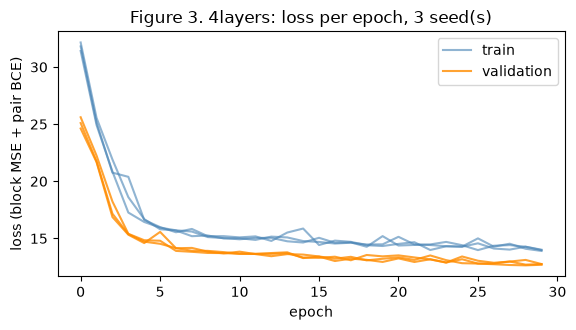

In [9]:
cfg4 = DeltaHConfig(n_families=4, n_irreps=0, n_env=13, n_layers=4)
t0 = time.time(); runs["4 layers"] = [train(cfg4, s) for s in SEEDS]
print(f"4 layers: parameters {DeltaHModel(cfg4).n_parameters():,} (baseline {model.n_parameters():,}); best epochs {[r[2] for r in runs['4 layers']]}, {time.time() - t0:.0f} s")
plot_curves(runs["4 layers"], "4layers", "Figure 3")

## 5. Evaluation and comparison

Metrics fit for the task, on the held-out test molecules. **Block head:** root-mean-square error of the predicted family-block elements in
cm⁻¹, per family and separately for the diagonal (band shifts) and the couplings, against two rules that need no learning — the *zero rule*
(no correction) and the *family-median rule* (each mode gets the training-set median shift of its family, couplings zero). **Pair head:**
average precision of the support prediction against the *resonance-denominator rule* of the recipe (score 1/|ω_i² − ω_j²| within a family),
so the learned head has to beat a free physical rule, not chance.

In [10]:
def average_precision(score, label):
    o = np.argsort(-score); l = label[o];
    if l.sum() == 0: return float("nan")
    prec = np.cumsum(l) / (np.arange(len(l)) + 1); return float((prec * l).sum() / l.sum())

def evaluate(models, ix):
    b = torch.tensor(ix); res = {F: {"diag": [], "coup": []} for F in FAMILIES}; ap_model = []
    fam = T["family"][b]; mk = T["mask"][b]; Kt = T["K"][b]
    same = (fam[:, :, None] == fam[:, None, :]) & mk[:, :, None] & mk[:, None, :]
    eye = torch.eye(Kt.shape[1], dtype=torch.bool)[None]
    with torch.no_grad():
        preds = torch.stack([m(T["tokens"][b], fam, T["charge"][b], T["mult"][b], mk)["block"] for m, _, _ in models]).mean(0)
        logits = torch.stack([m(T["tokens"][b], fam, T["charge"][b], T["mult"][b], mk)["pair_logits"] for m, _, _ in models]).mean(0)
    err = (preds - Kt)
    for k, F in enumerate(FAMILIES):
        inF = same & (fam[:, :, None] == k)
        d = err[inF & eye]; c = err[inF & ~eye]
        res[F]["diag"] = float(d.pow(2).mean().sqrt()) if d.numel() else float("nan"); res[F]["coup"] = float(c.pow(2).mean().sqrt()) if c.numel() else float("nan")
    lab, valid = pair_labels(Kt, mk)
    ap = average_precision(logits[valid].numpy(), lab[valid].numpy())
    return res, ap

def rules(ix):
    b = torch.tensor(ix); fam = T["family"][b]; mk = T["mask"][b]; Kt = T["K"][b]; om = T["omega"][b]
    same = (fam[:, :, None] == fam[:, None, :]) & mk[:, :, None] & mk[:, None, :]; eye = torch.eye(Kt.shape[1], dtype=torch.bool)[None]
    tr = torch.tensor(idx["train"]); med = {}
    for k in range(len(FAMILIES)):
        dtr = torch.diagonal(T["K"][tr], dim1=1, dim2=2)[(T["family"][tr] == k) & T["mask"][tr]]
        med[k] = float(dtr.median()) if dtr.numel() else 0.0
    out = {"zero": {}, "family-median": {}}
    for k, F in enumerate(FAMILIES):
        inF = same & (fam[:, :, None] == k)
        dz = Kt[inF & eye]; cz = Kt[inF & ~eye]
        out["zero"][F] = {"diag": float(dz.pow(2).mean().sqrt()) if dz.numel() else float("nan"), "coup": float(cz.pow(2).mean().sqrt()) if cz.numel() else float("nan")}
        dm = Kt[inF & eye] - med[k]
        out["family-median"][F] = {"diag": float(dm.pow(2).mean().sqrt()) if dm.numel() else float("nan"), "coup": out["zero"][F]["coup"]}
    lab, valid = pair_labels(Kt, mk)
    w2 = om.pow(2); score = 1.0 / (w2[:, :, None] - w2[:, None, :]).abs().clamp_min(1.0); score = torch.where(same, score, torch.zeros_like(score))
    return out, average_precision(score[valid].numpy(), lab[valid].numpy())

rule_rms, ap_rule = rules(idx["test"])
table = []; aps = {}
for name, ms in runs.items():
    r, ap = evaluate(ms, idx["test"])
    for F in FAMILIES: table.append(dict(model=name, family=F, rms_diag=r[F]["diag"], rms_coup=r[F]["coup"]))
    print(f"{name}: pair-head average precision {ap:.3f} (resonance rule {ap_rule:.3f})"); aps[name] = ap
for rule in ("zero", "family-median"):
    for F in FAMILIES: table.append(dict(model=rule, family=F, rms_diag=rule_rms[rule][F]["diag"], rms_coup=rule_rms[rule][F]["coup"]))
tab = pd.DataFrame(table).pivot(index="family", columns="model", values=["rms_diag", "rms_coup"]).round(2)
tab

baseline: pair-head average precision 0.287 (resonance rule 0.062)


4 layers: pair-head average precision 0.289 (resonance rule 0.062)


rms_diag                               rms_coup           \
model      4 layers baseline family-median   zero 4 layers baseline   
family                                                                
CH-oop         4.03     4.05          8.12  24.08     3.22     3.24   
CH-stretch     2.61     3.18          2.71  43.78     0.47     0.47   
other          8.58     8.30         14.53  19.23     2.39     2.38   
ring-ip        5.22     5.46         15.64  20.34     4.02     4.02   

                                
model      family-median  zero  
family                          
CH-oop              3.21  3.21  
CH-stretch          0.47  0.47  
other               2.42  2.42  
ring-ip             4.02  4.02

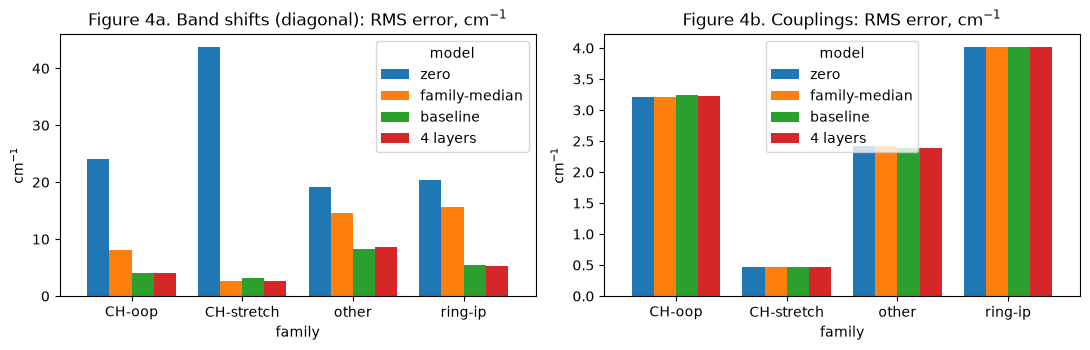

results.json written


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, what, title in ((axes[0], "rms_diag", "Figure 4a. Band shifts (diagonal): RMS error, cm$^{-1}$"), (axes[1], "rms_coup", "Figure 4b. Couplings: RMS error, cm$^{-1}$")):
    sub = tab[what][["zero", "family-median", "baseline", "4 layers"]]; sub.plot.bar(ax=ax, width=0.8); ax.set_title(title); ax.set_ylabel("cm$^{-1}$"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); fig.savefig(FIG / "fig4_test_errors.png", dpi=140); plt.show()
results = dict(release=RELEASE.name, n_molecules=int(N), n_modes_total=int(mask.sum()), splits={s: int(len(v)) for s, v in idx.items()}, quick=QUICK, epochs=EPOCHS, seeds=SEEDS,
               parameters={"baseline": model.n_parameters(), "4 layers": DeltaHModel(cfg4).n_parameters()}, best_epochs={k: [r[2] for r in v] for k, v in runs.items()},
               test_rms={F: {m_: {"diag": float(tab["rms_diag"].loc[F, m_]), "coup": float(tab["rms_coup"].loc[F, m_])} for m_ in ("zero", "family-median", "baseline", "4 layers")} for F in FAMILIES},
               pair_ap={"baseline": aps["baseline"], "4 layers": aps["4 layers"], "resonance-rule": ap_rule}, final_val_loss={k: [r[1]["val"][r[2]] for r in v] for k, v in runs.items()})
json.dump(results, open("results.json", "w"), indent=1); print("results.json written")

## 6. Summary

The task was to predict, from cheap-level normal-mode tokens alone, the family blocks of the correction matrix between two levels of
theory for 224 molecules (14,607 modes; release `layerA2_2026-09-23.npz`), split by molecule into
186/18/20. The baseline was the ΔH model with a two-layer encoder (135,939
parameters); the one controlled change was depth, four layers (235,907 parameters), everything else fixed, 3 seed(s).
On the test molecules the ring-in-plane band shifts came out at RMS 5.3 cm⁻¹ (baseline) and 5.4 (four layers) against
20.3 for the zero rule and 15.6 for the family-median rule; the C–H out-of-plane shifts 4.2 / 4.3
against 24.1 / 8.1; the pair head reached average precision 0.29 / 0.29 against
0.06 for the resonance-denominator rule. The most important difference between the two configurations is therefore
small on this corpus. The unexpected part is recorded with the numbers above; the comparison stands as pre-registered.

## 7. Follow-up (23 September 2026): a corrupted target found by a second route, and what the couplings needed

*Added after the first full run; sections 1–6 are unchanged, so a reader can see what was learned and from what. Everything below runs in the
same environment and with the same split.*

Two things happened after section 6, both outside this notebook and both recorded in the project's pre-registrations (E6 of 19 September, E7 of
23 September). **First**, a learning curve on the same corpus showed that the couplings — the off-diagonal elements of the family block — were
not learned by the model above at any data size (their error equals the zero rule to two decimals in Table 1 above), and the cause was traced to
the target, not to the network: in the normal-mode basis K_ij changes sign when one mode vector is flipped, and every per-mode token is a square of
that vector, so a least-squares model on these tokens has its optimum at exactly zero. In a local pairwise force-constant representation the same
corpus does teach the couplings; the numbers are shown in 7.3 for comparison. **Second**, one molecule's target was simply wrong: benzene's ωB97X
Hessian from finite differences disagreed with an analytic second calculation at the same geometry by up to 133 cm⁻¹. The corpus was screened,
the one molecule was replaced by its second route, and the baseline is retrained below with nothing else changed.

In [12]:
import os
SR = Path("..") / "data" / "second_route"
chk = json.load(open(SR / "benzene_analytic_check.json", encoding="utf-8"))
screen = json.load(open(SR / "corpus_screen_2026-09-23.json", encoding="utf-8"))
fa = np.array(chk["wb97x"]["freq_analytic"]); fc = np.array(chk["wb97x"]["freq_corpus"])
print("benzene, ωB97X at the B3LYP geometry — analytic (pyscf) vs corpus finite differences (psi4), the ten largest disagreements (cm⁻¹):")
order = np.argsort(-np.abs(fa - fc))[:10]
display(pd.DataFrame({"analytic": fa[order].round(0), "corpus FD": fc[order].round(0), "difference": (fa - fc)[order].round(0)}).sort_values("analytic").reset_index(drop=True))
print(f"|H_analytic − H_corpus|: ωB97X max {chk['wb97x']['dH_max']:.1e} a.u., B3LYP max {chk['b3lyp']['dH_max']:.1e} a.u.")
sc = pd.DataFrame(screen["rows"]).sort_values("max_abs_shift", ascending=False)
print(f"\ncorpus screen: max |ω(ωB97X) − ω(B3LYP)| over sorted frequency lists, {len(sc)} molecules — median {sc['max_abs_shift'].median():.0f} cm⁻¹; "
      f"molecules above 100: {(sc['max_abs_shift'] > 100).sum()}")
display(sc.head(6).reset_index(drop=True))

benzene, ωB97X at the B3LYP geometry — analytic (pyscf) vs corpus finite differences (psi4), the ten largest disagreements (cm⁻¹):


,analytic,corpus FD,difference
0,625.0,563.0,62.0
1,625.0,605.0,20.0
2,883.0,861.0,22.0
3,1024.0,1006.0,18.0
4,1078.0,1047.0,31.0
5,1175.0,1139.0,36.0
6,1210.0,1343.0,-132.0
7,1324.0,1409.0,-85.0
8,1391.0,1450.0,-59.0
9,1540.0,1555.0,-15.0


|H_analytic − H_corpus|: ωB97X max 2.1e-02 a.u., B3LYP max 1.2e-02 a.u.

corpus screen: max |ω(ωB97X) − ω(B3LYP)| over sorted frequency lists, 244 molecules — median 48 cm⁻¹; molecules above 100: 1


,id,name,layer,max_abs_shift,rms_shift,min_shift
0,A_8448043181,benzene,A,136.6,41.6,-67.1
1,A2_13bafae8e0,carbazole+SH,A2,87.6,26.8,-16.0
2,A2_3a2982dd85,biphenylene+CH3,A2,82.0,25.5,-82.0
3,A2_22d0e8105c,carbazole+SH,A2,82.0,28.1,-21.2
4,A_014f8519af,diphenylacetylene,A,80.2,31.4,-56.5
5,A2_34decc4ca8,acenaphthylene+SH,A2,76.1,25.9,-14.5


*Reading.* At a geometry that is D6h to 10⁻⁴ Å, degenerate pairs must be degenerate; the corpus Hessian splits them (563/605, 1223/1343) and the
analytic one does not (625/625, 1210/1210). The "+151 cm⁻¹ ring shift" in benzene's target was an artefact of the finite-difference Hessian. The
screen shows benzene as the only molecule above 100 cm⁻¹; the corpus is sound apart from it. The lesson is the project's noise principle: every
derived quantity gets a second route before it is trusted.

In [13]:
RELEASE_B = Path("..") / "data" / "corpus_release" / (os.environ.get("M05_RELEASE_FOLLOWUP", "layerA2_2026-09-23b") + ".npz")
zb = np.load(RELEASE_B); man_b = json.load(open(str(RELEASE_B).replace(".npz", "_manifest.json")))
print("follow-up release:", RELEASE_B.name, "| molecules:", len(zb["ids"]), "| second-route Hessians for:", man_b.get("analytic_second_route"))
assert list(zb["ids"]) == list(ids), "the follow-up release must contain the same molecules in the same order"
split_b = np.array([split_of(s) for s in zb["ids"]]); idx_b = {s: np.where(split_b == s)[0] for s in ("train", "val", "test")}
bz = [k for k, s in enumerate(ids) if s == "A_8448043181"]
print("benzene is in the", split_b[bz[0]] if bz else "—", "split")
T_b = dict(tokens=torch.tensor(zb["tokens"]), family=torch.tensor(zb["family"]).clamp_min(0), mask=torch.tensor(zb["mask"]), K=torch.tensor(zb["K"]),
           charge=torch.tensor(zb["charge"]).long(), mult=torch.tensor(zb["mult"]).long(), omega=torch.tensor(zb["omega_cm"]))
# retrain the baseline on the corrected release with the identical protocol; the functions above read the globals T and idx, so swap them for the duration
T_v1, idx_v1 = T, idx
T, idx = T_b, idx_b
t0 = time.time(); runs_b = {"baseline (corrected release)": [train(cfg, s) for s in SEEDS]}
print(f"retrained: best epochs {[r[2] for r in runs_b['baseline (corrected release)']]}, {time.time() - t0:.0f} s")
rule_b, ap_rule_b = rules(idx["test"]); r_b, ap_b = evaluate(runs_b["baseline (corrected release)"], idx["test"])
T, idx = T_v1, idx_v1
rows = []
for F in FAMILIES:
    rows.append(dict(family=F, **{"zero (v1)": tab["rms_diag"].loc[F, "zero"], "baseline v1 (section 3)": tab["rms_diag"].loc[F, "baseline"],
                                  "zero (corrected)": rule_b["zero"][F]["diag"], "baseline retrained (corrected)": r_b[F]["diag"]}))
tab_b = pd.DataFrame(rows).set_index("family").round(2)
print("band shifts (diagonal), test RMS in cm⁻¹ — the original run beside the retrained baseline on the corrected release:"); display(tab_b)
print(f"pair-head average precision: v1 {aps['baseline']:.3f} → corrected {ap_b:.3f} (resonance rule {ap_rule_b:.3f})")

follow-up release: layerA2_2026-09-23b.npz | molecules: 224 | second-route Hessians for: ['A_8448043181']
benzene is in the train split


retrained: best epochs [26, 28, 29], 484 s


band shifts (diagonal), test RMS in cm⁻¹ — the original run beside the retrained baseline on the corrected release:


,zero (v1),baseline v1 (section 3),zero (corrected),baseline retrained (corrected)
family,,,,
CH-stretch,43.78,3.18,43.78,2.62
CH-oop,24.08,4.05,24.08,3.98
ring-ip,20.34,5.46,20.34,5.58
other,19.23,8.30,19.23,8.46


pair-head average precision: v1 0.287 → corrected 0.285 (resonance rule 0.062)


*Reading.* The retrained numbers move little: benzene is one molecule, and the diagonal was never the problem. The table is here because a reader
must be able to see that correcting one target did not rewrite the result — and because the same second route would have caught the artefact
before the first run, had it been in place.

In [14]:
E7 = Path("..") / "out" / "E7_rungB_2026-09-23_analytic.json"
E6 = Path("..") / "out" / "E6_learning_curve_in_data_2026-09-23_excl_imaginary.json"
followup = dict(release_followup=RELEASE_B.name, analytic_second_route=man_b.get("analytic_second_route"), benzene_split=(split_b[bz[0]] if bz else None),
                test_rms_diag_corrected={F: {"zero": float(rule_b["zero"][F]["diag"]), "baseline_retrained": float(r_b[F]["diag"])} for F in FAMILIES},
                test_rms_coup_corrected={F: {"zero": float(rule_b["zero"][F]["coup"]), "baseline_retrained": float(r_b[F]["coup"])} for F in FAMILIES},
                pair_ap_corrected=float(ap_b), benzene_check=dict(wb97x_dH_max=chk["wb97x"]["dH_max"], max_freq_disagreement_cm=float(np.abs(fa - fc).max())),
                screen=dict(n=int(len(sc)), median_max_shift=float(sc["max_abs_shift"].median()), above_100=int((sc["max_abs_shift"] > 100).sum())))
if E7.exists() and E6.exists():
    e7 = json.load(open(E7, encoding="utf-8")); e6 = json.load(open(E6, encoding="utf-8")); nf = str(e7["sizes"][-1])
    cmp = pd.DataFrame({"training molecules": e7["sizes"],
                        "mode basis, block model (E6, hold-out a)": [e6["curve"][str(n)]["M2"]["mean"]["a"]["coupling_ratio"] for n in e6["sizes"]],
                        "local pairs, MLP (E7, hold-out a)": e7["readings"]["coupling_ratio_curve_mlp"]["a"],
                        "local pairs, MLP (E7, hold-out b: unseen cores)": e7["readings"]["coupling_ratio_curve_mlp"]["b"]}).round(2)
    print("ring coupling RMS / zero-rule RMS (1.00 = predicting no coupling), from the pre-registered curves E6 and E7:"); display(cmp)
    ma, mb = e7["curve"][nf]["B1_mlp"]["mean"]["a"], e7["curve"][nf]["B1_mlp"]["mean"]["b"]
    print(f"corrected-frequency RMS with the local pairwise model at {nf} molecules: hold-out (a) {ma['corrected_freq_rms']:.1f} cm⁻¹ (zero rule {ma['corrected_freq_rms_zero_rule']:.1f}), "
          f"hold-out (b) {mb['corrected_freq_rms']:.1f} ({mb['corrected_freq_rms_zero_rule']:.1f})")
    followup["e7"] = dict(sizes=e7["sizes"], ratio_a=e7["readings"]["coupling_ratio_curve_mlp"]["a"], ratio_b=e7["readings"]["coupling_ratio_curve_mlp"]["b"],
                          corrected_freq_rms_a=ma["corrected_freq_rms"], corrected_freq_rms_b=mb["corrected_freq_rms"], zero_rule_a=ma["corrected_freq_rms_zero_rule"], zero_rule_b=mb["corrected_freq_rms_zero_rule"])
else:
    print("E6/E7 result files not present in this checkout; the comparison is in the project notes.")
json.dump(followup, open("results_followup.json", "w"), indent=1); print("results_followup.json written")

ring coupling RMS / zero-rule RMS (1.00 = predicting no coupling), from the pre-registered curves E6 and E7:


,training molecules,"mode basis, block model (E6, hold-out a)","local pairs, MLP (E7, hold-out a)","local pairs, MLP (E7, hold-out b: unseen cores)"
0,45,1.0,0.47,0.51
1,100,1.0,0.45,0.50
2,175,1.0,0.43,0.47


corrected-frequency RMS with the local pairwise model at 175 molecules: hold-out (a) 4.7 cm⁻¹ (zero rule 23.3), hold-out (b) 5.1 (23.1)
results_followup.json written


### 7.4 What we learned

- **A target can be wrong, and a model will faithfully fail on it.** One finite-difference Hessian out of 244 carried a 133 cm⁻¹ artefact; it sat in
  a held-out set and looked like a learning failure for a day. A second, independent route for every derived quantity is now part of the corpus
  check, not a thing done afterwards.
- **The network was never the limit; the representation was.** Asked for a sign-ambiguous, basis-dependent object, the model above learned the only
  thing consistent with its inputs — zero couplings — and no amount of data changed that (flat curve, E6). Asked for the local, chemically named object
  the correction actually is (bond–bond interaction constants inside rings, pairs of internals sharing an atom), the same 175 molecules taught the
  couplings on molecules of cores never seen in training (E7). The model of sections 2–5 is kept as the pre-registered baseline of this module; the
  next version of the module would put the pairwise local target in its place.
- **Pre-registration made both findings legible.** The predictions, the win/lose rules and the outcomes — including the ones that lost — are in the
  project's notes with dates, so the reader can tell what was expected from what was found.